In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# ==========================================
# TASK 1: DATA PREPARATION
# Initial Dataset Inspection
# ==========================================

print("Dataset Shape:")
print(df.shape)

print("\nData Types and Non-Null Counts:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape:
(7043, 21)

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-nul

In [3]:
# Inspect TotalCharges before conversion

print("TotalCharges data type:", df["TotalCharges"].dtype)

blank_total_charges = df[df["TotalCharges"].str.strip() == ""]

print("Number of blank TotalCharges values:", len(blank_total_charges))

blank_total_charges[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

TotalCharges data type: object
Number of blank TotalCharges values: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [4]:
# ==========================================
# DATA CLEANING
# ==========================================

# Convert TotalCharges from object/string to numeric.
# Blank strings become NaN.
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges after conversion:")
print(df["TotalCharges"].isnull().sum())

# Remove the 11 rows with missing TotalCharges
df = df.dropna(subset=["TotalCharges"]).copy()

# customerID is only an identifier and provides no useful
# predictive information for churn modelling.
df.drop(columns=["customerID"], inplace=True)

print("\nShape after cleaning:", df.shape)
print("TotalCharges data type:", df["TotalCharges"].dtype)
print("Remaining missing values:", df.isnull().sum().sum())

Missing TotalCharges after conversion:
11

Shape after cleaning: (7032, 20)
TotalCharges data type: float64
Remaining missing values: 0


### Data Cleaning Decisions

The dataset initially contained 7,043 records and 21 columns, with no
duplicate rows. Although no standard null values were initially detected,
`TotalCharges` was stored as an object rather than a numerical variable.
Further inspection identified 11 blank-string values in this column.

`TotalCharges` was converted to a numeric data type using
`pd.to_numeric(errors="coerce")`, which converted the blank strings into
missing values. Since only 11 of 7,043 records (approximately 0.16%) were
affected, these records were removed rather than imputed. Removing such a
small proportion of the dataset avoids introducing artificial charge values
while having negligible impact on the available data.

The `customerID` column was also removed because it is a unique identifier
rather than a meaningful behavioral, demographic, or account feature and
therefore does not provide useful predictive information for customer churn.

Churn Counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentages:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


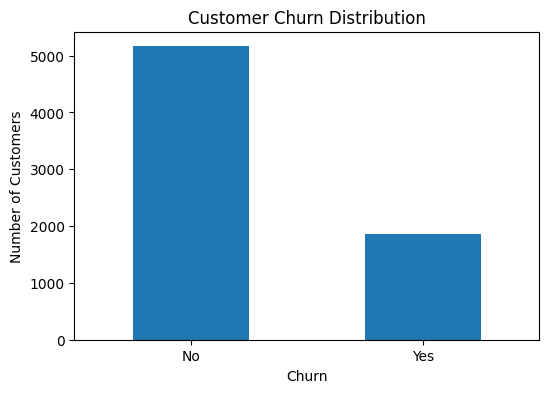

In [5]:
# ==========================================
# TARGET VARIABLE ANALYSIS
# ==========================================

print("Churn Counts:")
print(df["Churn"].value_counts())

print("\nChurn Percentages:")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

# Visualize class distribution
df["Churn"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

### Target Variable Analysis

The target variable contains 5,163 non-churn customers (73.42%) and
1,869 churn customers (26.58%). This indicates a moderate class imbalance.

Therefore, model performance should not be evaluated using accuracy alone.
Precision, recall, F1-score, and ROC-AUC will also be considered to ensure
that the models are properly evaluated on their ability to identify
customers who actually churn.

In [6]:
# ==========================================
# TASK 2: FEATURE ENGINEERING
# ==========================================

# 1. Average historical monthly spending
df["AvgMonthlySpend"] = np.where(
    df["tenure"] > 0,
    df["TotalCharges"] / df["tenure"],
    df["MonthlyCharges"]
)

# 2. Contract commitment level
contract_map = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}

df["ContractCommitment"] = df["Contract"].map(contract_map)

# 3. Number of optional services used by each customer
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = df[service_cols].eq("Yes").sum(axis=1)

# 4. Interaction between monthly cost and contract commitment
df["ChargeCommitmentInteraction"] = (
    df["MonthlyCharges"] *
    (df["ContractCommitment"] + 1)
)

# Inspect engineered features
df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "AvgMonthlySpend",
        "Contract",
        "ContractCommitment",
        "ServiceCount",
        "ChargeCommitmentInteraction"
    ]
].head(10)

,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,Contract,ContractCommitment,ServiceCount,ChargeCommitmentInteraction
0,1,29.85,29.85,29.850000,Month-to-month,0,1,29.85
1,34,56.95,1889.50,55.573529,One year,1,2,113.90
2,2,53.85,108.15,54.075000,Month-to-month,0,2,53.85
3,45,42.30,1840.75,40.905556,One year,1,3,84.60
4,2,70.70,151.65,75.825000,Month-to-month,0,0,70.70
5,8,99.65,820.50,102.562500,Month-to-month,0,3,99.65
6,22,89.10,1949.40,88.609091,Month-to-month,0,2,89.10
7,10,29.75,301.90,30.190000,Month-to-month,0,1,29.75
8,28,104.80,3046.05,108.787500,Month-to-month,0,4,104.80
9,62,56.15,3487.95,56.257258,One year,1,2,112.30


### Engineered Feature Justification

**1. AvgMonthlySpend:**  
This feature estimates a customer's average historical monthly spending
using their total charges and tenure. It may reveal long-term spending
patterns that are not completely represented by the customer's current
MonthlyCharges value.

**2. ContractCommitment:**  
The original Contract variable contains a genuine ordering from
month-to-month to one-year and two-year contracts. Representing this
commitment numerically may help capture the relationship between stronger
contractual commitment and churn behavior.

**3. ServiceCount:**  
This feature represents the number of optional services used by each
customer. Customers using several services may be more integrated into the
company's ecosystem and could therefore exhibit different churn behavior
from customers using very few services.

**4. ChargeCommitmentInteraction:**  
This feature combines monthly financial cost with contract commitment.
Customers paying similar monthly charges may behave differently depending
on whether they have a short-term or long-term contract, so this interaction
may expose information that either variable alone does not capture.

In [7]:
# ==========================================
# CATEGORICAL ENCODING
# ==========================================

# Convert target variable to binary:
# No = 0, Yes = 1
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Identify remaining categorical predictor columns
categorical_cols = [
    col for col in df.select_dtypes(include="object").columns
    if col != "Churn"
]

print("Categorical columns to encode:")
print(categorical_cols)

# One-hot encode nominal categorical variables
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("\nOriginal shape:", df.shape)
print("Encoded shape:", df_encoded.shape)

print("\nRemaining data types:")
print(df_encoded.dtypes.value_counts())

print("\nMissing values:", df_encoded.isnull().sum().sum())

Categorical columns to encode:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Original shape: (7032, 24)
Encoded shape: (7032, 35)

Remaining data types:
int64      31
float64     4
Name: count, dtype: int64

Missing values: 0


### Categorical Encoding

The target variable `Churn` was converted into binary form, where
No = 0 and Yes = 1.

One-hot encoding was used for the remaining nominal categorical variables.
This approach avoids assigning arbitrary numerical rankings to categories
that do not possess a genuine ordinal relationship.

`ContractCommitment` was treated differently because contract duration has
a meaningful order: month-to-month, one-year, and two-year contracts
represent increasing levels of commitment.

In [8]:
# ==========================================
# TASK 3: TRAIN / TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

# Separate predictors and target
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# 80% training, 20% testing
# Stratification preserves the churn class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining Churn Distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest Churn Distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training set: (5625, 34)
Test set: (1407, 34)

Training Churn Distribution:
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64

Test Churn Distribution:
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


### Train/Test Split

The prepared dataset was divided into 80% training data and 20% testing
data. A fixed random state of 42 was used for reproducibility.

Stratification was applied using the Churn target so that approximately the
same proportion of churn and non-churn customers is maintained in both the
training and testing sets.

In [9]:
# Numerical features that require scaling
numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AvgMonthlySpend",
    "ContractCommitment",
    "ServiceCount",
    "ChargeCommitmentInteraction"
]

print("Numerical features selected for scaling:")
for col in numeric_cols:
    print("-", col)

Numerical features selected for scaling:
- tenure
- MonthlyCharges
- TotalCharges
- AvgMonthlySpend
- ContractCommitment
- ServiceCount
- ChargeCommitmentInteraction


In [10]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

X_train_std = X_train.copy()
X_test_std = X_test.copy()

# FIT only on training data
X_train_std[numeric_cols] = standard_scaler.fit_transform(
    X_train[numeric_cols]
)

# Test data uses statistics learned from training data
X_test_std[numeric_cols] = standard_scaler.transform(
    X_test[numeric_cols]
)

print("StandardScaler applied successfully.")

X_train_std[numeric_cols].describe().round(3)

StandardScaler applied successfully.


,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,ContractCommitment,ServiceCount,ChargeCommitmentInteraction
count,5625.000,5625.000,5625.000,5625.000,5625.000,5625.000,5625.000
mean,-0.000,0.000,0.000,-0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.286,-1.548,-1.003,-1.695,-0.831,-1.115,-1.126
25%,-0.960,-0.970,-0.830,-0.940,-0.831,-1.115,-0.662
50%,-0.145,0.186,-0.392,0.189,-0.831,-0.031,-0.347
75%,0.955,0.832,0.659,0.841,0.368,0.511,0.366
max,1.607,1.782,2.805,1.866,1.567,2.138,3.113


In [11]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

X_train_mm = X_train.copy()
X_test_mm = X_test.copy()

# Again, fit only on training data
X_train_mm[numeric_cols] = minmax_scaler.fit_transform(
    X_train[numeric_cols]
)

X_test_mm[numeric_cols] = minmax_scaler.transform(
    X_test[numeric_cols]
)

print("MinMaxScaler applied successfully.")

X_train_mm[numeric_cols].describe().round(3)

MinMaxScaler applied successfully.


,tenure,MonthlyCharges,TotalCharges,AvgMonthlySpend,ContractCommitment,ServiceCount,ChargeCommitmentInteraction
count,5625.000,5625.000,5625.000,5625.000,5625.000,5625.000,5625.000
mean,0.445,0.465,0.263,0.476,0.346,0.343,0.266
std,0.346,0.300,0.263,0.281,0.417,0.307,0.236
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.113,0.174,0.045,0.212,0.000,0.000,0.110
50%,0.394,0.521,0.161,0.529,0.000,0.333,0.184
75%,0.775,0.715,0.437,0.712,0.500,0.500,0.352
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


### Feature Scaling

Two scaling techniques were evaluated: **StandardScaler** and
**MinMaxScaler**.

StandardScaler transforms numerical features so that they are centered
around a mean of approximately zero with a standard deviation of one.
MinMaxScaler transforms numerical features to a range between 0 and 1.

Scaling is particularly important for distance- and margin-based algorithms
such as K-Nearest Neighbors and Support Vector Machines because features
with larger numerical magnitudes could otherwise dominate distance or
margin calculations. Logistic Regression can also benefit from standardized
features.

Tree-based algorithms such as Decision Trees and Random Forests do not
require feature scaling because their decisions are based on feature
thresholds rather than distances between observations.

Both scalers were fitted **only on the training data** and then applied to
the test data. Fitting a scaler on the complete dataset would allow
information from the test set to influence preprocessing, causing data
leakage and producing an overly optimistic evaluation.

StandardScaler was selected for the scale-sensitive models because it places
continuous numerical features on comparable scales while preserving their
relative variation. The unscaled dataset will be retained for the
tree-based models.

## Task 4: Model Building

Five classification algorithms were selected to provide a comparison
across different modeling approaches:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Support Vector Machine (SVM)
4. Decision Tree
5. Random Forest

Standardized data is used for Logistic Regression, KNN, and SVM because
these algorithms can be affected by differences in feature scales.
Decision Tree and Random Forest are trained using the unscaled data because
tree-based algorithms are scale-invariant.

In [12]:
# ==========================================
# TASK 4: MODEL BUILDING
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize models
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

svm_model = SVC(
    probability=True,
    random_state=42
)

dt_model = DecisionTreeClassifier(
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train scale-sensitive models on standardized data
log_model.fit(X_train_std, y_train)
knn_model.fit(X_train_std, y_train)
svm_model.fit(X_train_std, y_train)

# Train tree-based models on original unscaled data
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("All five models trained successfully.")

All five models trained successfully.


In [13]:
# ==========================================
# MODEL EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, model, X_eval, y_eval):

    predictions = model.predict(X_eval)
    probabilities = model.predict_proba(X_eval)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, predictions),
        "Precision": precision_score(y_eval, predictions),
        "Recall": recall_score(y_eval, predictions),
        "F1-Score": f1_score(y_eval, predictions),
        "ROC-AUC": roc_auc_score(y_eval, probabilities)
    }


results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        log_model,
        X_test_std,
        y_test
    )
)

results.append(
    evaluate_model(
        "K-Nearest Neighbors",
        knn_model,
        X_test_std,
        y_test
    )
)

results.append(
    evaluate_model(
        "Support Vector Machine",
        svm_model,
        X_test_std,
        y_test
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        dt_model,
        X_test,
        y_test
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        rf_model,
        X_test,
        y_test
    )
)

results_df = pd.DataFrame(results)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8038,0.6503,0.5668,0.6057,0.8363
1,K-Nearest Neighbors,0.7633,0.5553,0.5508,0.5530,0.7798
2,Support Vector Machine,0.7974,0.6540,0.5053,0.5701,0.7827
3,Decision Tree,0.7122,0.4608,0.4866,0.4733,0.6400
4,Random Forest,0.7854,0.6169,0.5080,0.5572,0.8224


In [14]:
# Rank models by ROC-AUC
results_ranked = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("Model Performance Ranking:")
display(results_ranked.round(4))

Model Performance Ranking:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8038,0.6503,0.5668,0.6057,0.8363
1,Random Forest,0.7854,0.6169,0.5080,0.5572,0.8224
2,Support Vector Machine,0.7974,0.6540,0.5053,0.5701,0.7827
3,K-Nearest Neighbors,0.7633,0.5553,0.5508,0.5530,0.7798
4,Decision Tree,0.7122,0.4608,0.4866,0.4733,0.6400


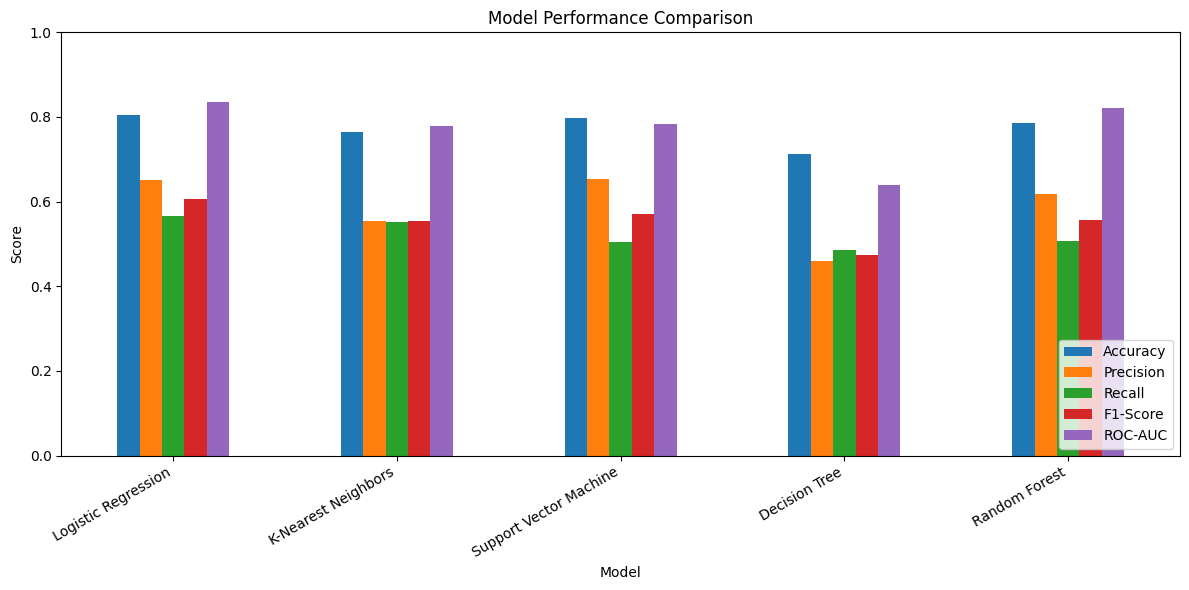

In [15]:
# ==========================================
# MODEL PERFORMANCE VISUALIZATION
# ==========================================

results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Cross-Validation

In addition to the held-out test set, 5-fold stratified cross-validation
was performed on the training data. Stratified folds preserve the class
distribution within each fold.

F1-score was selected as the cross-validation metric because the target
classes are imbalanced and F1 considers both precision and recall rather
than measuring overall accuracy alone.

In [16]:
# ==========================================
# 5-FOLD CROSS-VALIDATION
# ==========================================

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

# Logistic Regression - scaled
scores = cross_val_score(
    log_model,
    X_train_std,
    y_train,
    cv=cv,
    scoring="f1"
)
cv_results.append(["Logistic Regression", scores.mean(), scores.std()])

# KNN - scaled
scores = cross_val_score(
    knn_model,
    X_train_std,
    y_train,
    cv=cv,
    scoring="f1"
)
cv_results.append(["K-Nearest Neighbors", scores.mean(), scores.std()])

# SVM - scaled
scores = cross_val_score(
    svm_model,
    X_train_std,
    y_train,
    cv=cv,
    scoring="f1"
)
cv_results.append(["Support Vector Machine", scores.mean(), scores.std()])

# Decision Tree - unscaled
scores = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)
cv_results.append(["Decision Tree", scores.mean(), scores.std()])

# Random Forest - unscaled
scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)
cv_results.append(["Random Forest", scores.mean(), scores.std()])


cv_df = pd.DataFrame(
    cv_results,
    columns=["Model", "Mean CV F1", "CV Std"]
)

display(
    cv_df.sort_values(
        "Mean CV F1",
        ascending=False
    ).round(4)
)

,Model,Mean CV F1,CV Std
0,Logistic Regression,0.5931,0.0223
2,Support Vector Machine,0.5779,0.0100
4,Random Forest,0.5663,0.0188
1,K-Nearest Neighbors,0.5578,0.0103
3,Decision Tree,0.5031,0.0236


In [17]:
# Add cross-validation results to test-set results
final_results = results_df.merge(
    cv_df,
    on="Model"
)

final_results = final_results.sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("FINAL MODEL COMPARISON")
display(final_results.round(4))

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Mean CV F1,CV Std
0,Logistic Regression,0.8038,0.6503,0.5668,0.6057,0.8363,0.5931,0.0223
1,Random Forest,0.7854,0.6169,0.5080,0.5572,0.8224,0.5663,0.0188
2,Support Vector Machine,0.7974,0.6540,0.5053,0.5701,0.7827,0.5779,0.0100
3,K-Nearest Neighbors,0.7633,0.5553,0.5508,0.5530,0.7798,0.5578,0.0103
4,Decision Tree,0.7122,0.4608,0.4866,0.4733,0.6400,0.5031,0.0236


## Task 5: Algorithm Research and Justification

### Model Performance Analysis

Logistic Regression achieved the strongest overall performance with an
accuracy of **80.38%**, precision of **65.03%**, recall of **56.68%**,
F1-score of **60.57%**, and ROC-AUC of **83.63%**. It also achieved the
highest mean cross-validation F1-score of **59.31%**, indicating that its
performance was relatively consistent across different training folds.

Random Forest ranked second based on ROC-AUC, achieving **82.24%**, but
produced lower recall and F1-score than Logistic Regression. Support Vector
Machine achieved the highest precision (**65.40%**) but had lower recall,
F1-score, and ROC-AUC.

Decision Tree produced the weakest overall performance, with an ROC-AUC of
only **64.00%**. This suggests that a single unrestricted tree may have
overfit patterns in the training data and generalized poorly to unseen
customers.

Because the dataset is moderately imbalanced, ROC-AUC, F1-score, precision,
and recall were considered alongside accuracy when selecting the final
model.

### Algorithm Comparison

#### Logistic Regression
Logistic Regression estimates the probability of a binary outcome by
modeling the log-odds as a linear combination of the input features. It is
well suited to binary classification problems such as customer churn and
works effectively with one-hot encoded categorical variables. However, it
primarily models linear relationships unless interaction terms or nonlinear
features are explicitly engineered.

#### K-Nearest Neighbors
KNN classifies observations according to the classes of nearby observations
in feature space. Because it relies directly on distance calculations,
feature scaling is important. KNN can become less effective when the number
of dimensions increases, which is relevant here because one-hot encoding
expanded the Telco dataset to 35 columns.

#### Support Vector Machine
SVM attempts to identify a decision boundary that maximizes the margin
between classes. It is sensitive to differences in feature scale, which is
why standardized features were used. Kernel-based SVMs can represent
nonlinear decision boundaries, although they can be more computationally
expensive and less interpretable than Logistic Regression.

#### Decision Tree
Decision Trees recursively divide the feature space using decision rules.
They naturally capture nonlinear relationships and interactions and do not
require feature scaling. However, individual trees can easily overfit
training data, which can reduce their ability to generalize to unseen
customers.

#### Random Forest
Random Forest combines predictions from many decision trees trained using
different bootstrap samples and random subsets of features. This generally
reduces the variance and overfitting associated with a single Decision Tree.
It can model complex nonlinear relationships and does not require feature
scaling. Its main disadvantage compared with Logistic Regression is reduced
interpretability and greater computational complexity.

### Relationship to the Telco Dataset

The Telco Customer Churn dataset contains a mixture of numerical and
categorical customer attributes. After one-hot encoding, the categorical
variables were represented as binary numerical features, making the data
suitable for Logistic Regression.

The dataset also contains correlated customer characteristics. For example,
tenure, total charges, monthly charges, contract type, and service usage may
contain overlapping information about customer behavior. Engineered
features such as `AvgMonthlySpend`, `ServiceCount`, `ContractCommitment`,
and `ChargeCommitmentInteraction` were introduced to expose additional
relationships to the models.

The target is moderately imbalanced, with approximately **73.42%**
non-churn customers and **26.58%** churn customers. Consequently, accuracy
alone could give a misleading impression of performance, so precision,
recall, F1-score, and ROC-AUC were also evaluated.

The weaker performance of KNN may partly reflect the higher-dimensional
feature space created through one-hot encoding. Meanwhile, the weak
Decision Tree result suggests that a single tree did not generalize as well
as the other models. Random Forest improved considerably over the single
Decision Tree by combining multiple trees, but it still did not outperform
Logistic Regression on this dataset.

### Best-Suited Algorithm

Based on both the empirical results and the characteristics of the dataset,
**Logistic Regression was selected as the best-suited algorithm among the
five models tested**.

It achieved the highest test accuracy (**80.38%**), F1-score (**60.57%**),
ROC-AUC (**83.63%**), and mean cross-validation F1-score (**59.31%**).
Its cross-validation standard deviation was also relatively low
(**0.0223**), suggesting reasonably stable performance across folds.

The result is plausible for this dataset because customer churn can be
influenced by additive effects from factors such as tenure, contract
commitment, monthly costs, and subscribed services. One-hot encoding makes
the categorical attributes directly usable by Logistic Regression, while
the engineered interaction features allow some relationships beyond the
original raw variables to be represented.

Another advantage is interpretability. In a churn setting, understanding
which customer characteristics increase or decrease churn probability can
be valuable in addition to producing accurate predictions.

### Limitation and Alternative

A major limitation of Logistic Regression is its assumption that the
log-odds of the target can be represented as a linear combination of the
input features. Complex nonlinear relationships may therefore be missed
unless they are represented through engineered features or transformations.

Random Forest would be preferable if the dataset contained stronger
nonlinear relationships and complex feature interactions that could not be
represented adequately through feature engineering. Random Forest can model
such relationships automatically and is also less dependent on feature
scaling, although this comes at the cost of reduced interpretability.

### References

1. Scikit-learn Developers. *Logistic Regression*. Scikit-learn
   Documentation. https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

2. Scikit-learn Developers. *Nearest Neighbors*. Scikit-learn
   Documentation. https://scikit-learn.org/stable/modules/neighbors.html

3. Scikit-learn Developers. *Support Vector Machines*. Scikit-learn
   Documentation. https://scikit-learn.org/stable/modules/svm.html

4. Scikit-learn Developers. *Decision Trees*. Scikit-learn
   Documentation. https://scikit-learn.org/stable/modules/tree.html

5. Scikit-learn Developers. *Ensembles: Gradient Boosting, Random
   Forests, Bagging, Voting, Stacking*. Scikit-learn Documentation.
   https://scikit-learn.org/stable/modules/ensemble.html

## Conclusion

This project developed and compared five machine learning classifiers for
predicting customer churn using the IBM Telco Customer Churn dataset.

The data was cleaned by resolving invalid `TotalCharges` values and removing
the non-predictive customer identifier. Four additional features were
engineered to represent customer spending, service usage, contract
commitment, and interactions between cost and commitment. Categorical
features were then encoded and numerical features were evaluated using both
StandardScaler and MinMaxScaler.

Five classification algorithms were evaluated using an 80/20 stratified
train-test split and 5-fold stratified cross-validation.

Among the tested models, **Logistic Regression produced the strongest
overall performance**, achieving:

- Accuracy: **80.38%**
- Precision: **65.03%**
- Recall: **56.68%**
- F1-score: **60.57%**
- ROC-AUC: **83.63%**
- Mean Cross-Validation F1: **59.31%**

Therefore, Logistic Regression was selected as the preferred model for this
dataset. It provided the best combination of predictive performance,
cross-validation stability, and interpretability among the algorithms
evaluated.